# Why correct market prices do not settle public value

Suppose an asset pays especially well in an automation state in which workers' consumption is scarce. International investors can price that asset correctly and a worker-oriented government can still value it more highly. The disagreement is not about the asset's market return. It is about who receives consumption in each state.

This notebook derives that distinction and illustrates it with two states. The numerical values are chosen to expose the mechanism; they are not a calibration.

## Two valuations of the same payoff

Workers cannot trade the external risky claim directly. The government maximizes worker welfare and chooses worker consumption, taxes, safe finance, and—when access is allowed—a public holding of the claim. International investors set prices in a small-open, price-taking closure and absorb residual positions. Technology, world prices, ownership, the shock law, the commitment convention, and the inherited state $(S_0,M_0)$ are held fixed.

For a payoff $X_{t+1}$, its market value is

$$
P_t=\mathbb E_t[m_I X_{t+1}],
$$

where $m_I$ is the international investor's stochastic discount factor. The government instead values the public resources delivered by the claim at

$$
G_t=\mathbb E_t[m_G X_{t+1}].
$$

The fiscal kernel $m_G$ follows an extra unit of public resources through taxes and transfers into worker consumption. Writing $\Theta=m_G/m_I$ isolates the source of disagreement. If $\Theta$ is constant, the two kernels rank state-contingent payoffs in the same way and differ only by a normalization; equality $G_t=P_t$ for every payoff requires $\Theta=1$ on the relevant states.

## A two-state example

The calculation keeps probabilities and the market pricing kernel fixed. It makes public resources relatively valuable in the worker-downside state and lets the claim pay mostly in that state. The bar height is each state's contribution to the claim's total value.

| State | Probability | Market SDF | Fiscal / market SDF | Claim payoff |
|---|---:|---:|---:|---:|
| worker downside | 0.50 | 1.10 | 1.50 | 1.40 |
| shared upside | 0.50 | 0.90 | 0.70 | 0.20 |

Market value of the claim: **0.860**

Fiscal value of the same claim: **1.218**

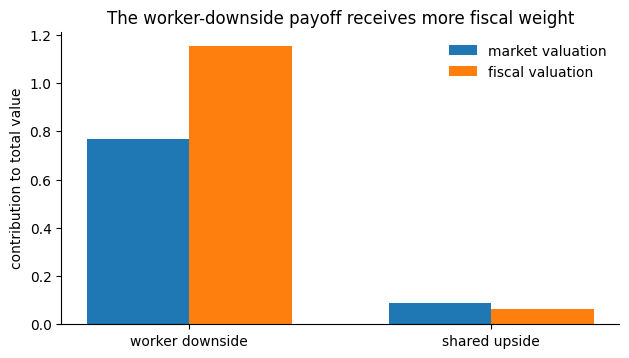

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

states = ["worker downside", "shared upside"]
probability = np.array([0.5, 0.5])
market_sdf = np.array([1.10, 0.90])
fiscal_to_market_ratio = np.array([1.50, 0.70])
fiscal_sdf = market_sdf * fiscal_to_market_ratio
claim_payoff = np.array([1.40, 0.20])

market_contribution = probability * market_sdf * claim_payoff
fiscal_contribution = probability * fiscal_sdf * claim_payoff
market_value = market_contribution.sum()
fiscal_value = fiscal_contribution.sum()

lines = [
    "| State | Probability | Market SDF | Fiscal / market SDF | Claim payoff |",
    "|---|---:|---:|---:|---:|",
]
for label, p, m_i, ratio, payoff in zip(
    states, probability, market_sdf, fiscal_to_market_ratio, claim_payoff
):
    lines.append(f"| {label} | {p:.2f} | {m_i:.2f} | {ratio:.2f} | {payoff:.2f} |")
lines.extend(
    [
        "",
        f"Market value of the claim: **{market_value:.3f}**",
        "",
        f"Fiscal value of the same claim: **{fiscal_value:.3f}**",
    ]
)
display(Markdown("\n".join(lines)))

fig, ax = plt.subplots(figsize=(7.2, 3.8))
x = np.arange(len(states))
width = 0.34
ax.bar(x - width / 2, market_contribution, width, label="market valuation")
ax.bar(x + width / 2, fiscal_contribution, width, label="fiscal valuation")
ax.set_xticks(x, states)
ax.set_ylabel("contribution to total value")
ax.set_title("The worker-downside payoff receives more fiscal weight")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Portfolio choice reconciles one traded direction

In the Brownian model, let $\sigma_I$ be the claim's vector of shock loadings, $\lambda_I$ the market price of those risks, and $\lambda_G(s)$ the government's fiscal price of risk when it holds $s$ units of the claim. Conditional on a smooth Ramsey solution, the derivative of the Hamiltonian with respect to the holding satisfies

$$
\frac{H_s(s)}{V_N}
=
\sigma_I^\top\!\left[\lambda_I-\lambda_G(s)\right].
$$

At an unconstrained interior choice $s^*$, this projection is zero. The government and the market then agree along the return delivered by the traded claim. They need not agree about a shock direction to which the claim has no exposure. If a portfolio bound binds, the corresponding Kuhn–Tucker inequality replaces the equality.

This is a conditional characterization of any smooth interior optimum, not an existence or uniqueness result for the full Ramsey problem. The underlying public-portfolio claim has not yet completed the project's proof audit.

## The three instruments reach different margins

| Instrument | What it moves | What it cannot reproduce on its own |
|---|---|---|
| Safe borrowing or saving | Resources across dates at the safe rate | A payoff that differs across simultaneous shock directions |
| Risky public claim | Resources along the claim's payoff vector | The component of fiscal exposure orthogonal to that vector |
| Capital tax | Current factor income and future capital accumulation | An inherited asset payoff at the instant of an inaccessible shock |

The risky claim is therefore useful when its payoff is high in states with a high fiscal value of public funds. Its market cost is the opposing force. Worker scarcity need not mean that worker consumption falls in levels: the same relative wedge can arise when workers gain, but investors gain more. The worker-downside state above is one illustration, not the definition of the mechanism.

The example establishes neither the optimal holding nor a welfare gain; it shows why correct pricing does not make the public and private valuation problems identical.

## Reproduce and trace

- Brownian source: [Nathan-Barnard/tai-public-finance at commit 971cab1](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Analytical objects: the SDF and traded-direction characterizations recorded as R07 and R20
- Current use: conditional analytical exposition plus an illustration; no numerical optimum or welfare magnitude
- Environment: this repository's requirements-dev.txt

Run from the repository root:

    jupyter nbconvert --to notebook --execute --inplace notebooks/01_public_intermediation_problem.ipynb